In [2]:
!pip install chronos-forecasting

  Using cached chronos_forecasting-1.3.0-py3-none-any.whl.metadata (30 kB)
  Using cached accelerate-0.34.2-py3-none-any.whl.metadata (19 kB)
  Using cached transformers-4.46.3-py3-none-any.whl.metadata (44 kB)
  Using cached huggingface_hub-0.26.3-py3-none-any.whl.metadata (13 kB)
  Using cached safetensors-0.4.5-cp312-cp312-macosx_11_0_arm64.whl.metadata (3.8 kB)
  Using cached tokenizers-0.20.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.7 kB)
Using cached chronos_forecasting-1.3.0-py3-none-any.whl (28 kB)
Using cached accelerate-0.34.2-py3-none-any.whl (324 kB)
Using cached transformers-4.46.3-py3-none-any.whl (10.0 MB)
Using cached huggingface_hub-0.26.3-py3-none-any.whl (447 kB)
Using cached safetensors-0.4.5-cp312-cp312-macosx_11_0_arm64.whl (381 kB)
Using cached tokenizers-0.20.3-cp312-cp312-macosx_11_0_arm64.whl (2.6 MB)


In [5]:
import pandas as pd  # requires: pip install pandas
import torch
from chronos import BaseChronosPipeline

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",  
    device_map="cpu",  # use "cpu" for CPU inference
    torch_dtype=torch.bfloat16,
)

df = pd.read_csv(
    "https://raw.githubusercontent.com/AileenNielsen/TimeSeriesAnalysisWithPython/master/data/AirPassengers.csv"
)

# context must be either a 1D tensor, a list of 1D tensors,
# or a left-padded 2D tensor with batch as the first dimension
# quantiles is an fp32 tensor with shape [batch_size, prediction_length, num_quantile_levels]
# mean is an fp32 tensor with shape [batch_size, prediction_length]
quantiles, mean = pipeline.predict_quantiles(
    context=torch.tensor(df["#Passengers"], dtype=torch.float32),
    prediction_length=12,
    quantile_levels=[0.1, 0.5, 0.9],
)



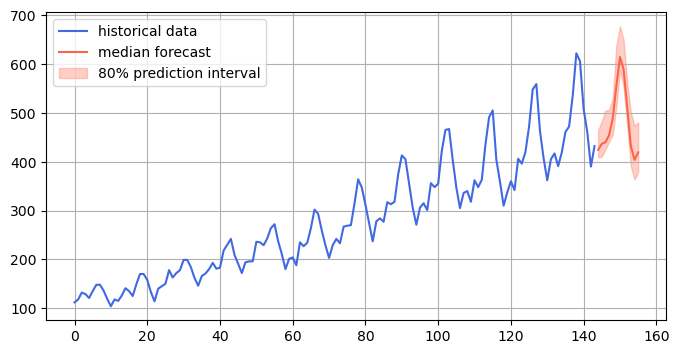

In [6]:
import matplotlib.pyplot as plt  # requires: pip install matplotlib

forecast_index = range(len(df), len(df) + 12)
low, median, high = quantiles[0, :, 0], quantiles[0, :, 1], quantiles[0, :, 2]

plt.figure(figsize=(8, 4))
plt.plot(df["#Passengers"], color="royalblue", label="historical data")
plt.plot(forecast_index, median, color="tomato", label="median forecast")
plt.fill_between(forecast_index, low, high, color="tomato", alpha=0.3, label="80% prediction interval")
plt.legend()
plt.grid()
plt.show()

In [8]:
import pandas as pd
import torch
from chronos import ChronosPipeline

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.bfloat16,
)

df = pd.read_csv("https://raw.githubusercontent.com/AileenNielsen/TimeSeriesAnalysisWithPython/master/data/AirPassengers.csv")

# context must be either a 1D tensor, a list of 1D tensors,
# or a left-padded 2D tensor with batch as the first dimension
context = torch.tensor(df["#Passengers"])
embeddings, tokenizer_state = pipeline.embed(context)

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

In [ ]:
from datasets import load_dataset

ds = load_dataset("autogluon/chronos_datasets", "dominick")